In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import os

# Settings 
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

### 1. Load Preprocesssed Data (10 pts)  
* X_train shape: (768, 9)
* X_test shape: (154, 9)
* Number of numeric columns: 7
* Number of categorical columns: 2
* Which columns are features being made from:
    - glazing area
    - Surface to wall
    - Overall height and and surface area

In [101]:
df = pd.read_csv('data/processed/df_dropped.csv')

X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv')
y_test = pd.read_csv('data/processed/y_test.csv')

print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 614 rows x 8 columns
y_train Loaded: 614 rows x 1 columns
X_test Loaded: 154 rows x 8 columns
y_test Loaded: 154 rows x 1 columns


In [104]:
X_train.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist
0,0.82,612.5,318.5,147.0,7.0,2,0.10,1
1,0.64,784.0,343.0,220.5,3.5,4,0.40,2
2,0.86,588.0,294.0,147.0,7.0,4,0.25,2
3,0.90,563.5,318.5,122.5,7.0,4,0.25,1
4,0.66,759.5,318.5,220.5,3.5,5,0.10,4


In [106]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'\nNumerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

print("\nColumns:")
print(X_train.columns.tolist())

print("\nDtypes:")
print(X_train.dtypes.sort_index())

print("\nTarget distribution:")
print(y_train.value_counts(dropna=False))

(614, 8)
(154, 8)
(614, 1)
(154, 1)

Numerical (8): ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation', 'glazing_area', 'glazing_area_dist']
Categorical (0): []

Columns:
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation', 'glazing_area', 'glazing_area_dist']

Dtypes:
glazing_area            float64
glazing_area_dist         int64
orientation               int64
overall_height          float64
relative_compactness    float64
roof_area               float64
surface_area            float64
wall_area               float64
dtype: object

Target distribution:
heating_load
15.16           6
15.09           4
15.23           4
12.63           3
13.00           3
               ..
16.73           1
16.66           1
16.64           1
16.62           1
43.10           1
Name: count, Length: 490, dtype: int64


### 2. Create New Features  
Create 4 new features
* Surface to wall ratio
* Overall height and surface area interaction
* Binary marker to indicate a building has a higher than average glazing area 

In [110]:
# Surface to wall ratio
X_train['surface_wall_ratio'] = X_train['surface_area'] / X_train['wall_area']
X_test['surface_wall_ratio'] = X_test['surface_area'] / X_test['wall_area']

# Check  
print(X_train['surface_wall_ratio'].describe())

count    614.000000
mean       2.144877
std        0.365646
min        1.588235
25%        1.857143
50%        2.200000
75%        2.471154
max        2.800000
Name: surface_wall_ratio, dtype: float64


In [112]:
# Height and Surface Area interaction
X_train['height_surface_interaction'] = X_train['overall_height'] * X_train['surface_area']
X_test['height_surface_interaction'] = X_test['overall_height'] * X_test['surface_area']

print(X_train['height_surface_interaction'].describe())

count     614.000000
mean     3385.728420
std       820.801377
min      2401.000000
25%      2593.937500
50%      2829.750000
75%      4116.000000
max      4630.500000
Name: height_surface_interaction, dtype: float64


In [115]:
#Flag any Glazing Area above th median as High glazing
median_glazing = X_train['glazing_area'].median()

X_train['high_glazing'] = (X_train['glazing_area'] > median_glazing).astype(int)
X_test['high_glazing'] = (X_test['glazing_area'] > median_glazing).astype(int)

print(X_train['high_glazing'].value_counts())

high_glazing
0    418
1    196
Name: count, dtype: int64


In [117]:
#Check shapes
print("Updated X_train shape:", X_train.shape)
print("Updated X_test shape:", X_test.shape)

Updated X_train shape: (614, 11)
Updated X_test shape: (154, 11)


### 3. Encode Categorical Features
* One hot encode orientation and glazing_area_dist

In [121]:
# One hot encoded orientation and glazing area
X_train = pd.get_dummies(X_train, columns=['orientation', 'glazing_area_dist'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['orientation', 'glazing_area_dist'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [123]:
#Check columns and shapes
print(X_train.select_dtypes(include='object').columns)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Index([], dtype='object')
X_train shape: (614, 17)
X_test shape: (154, 17)


# 4 Scale Numerical Freatures

In [127]:
scale_cols=['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 
            'overall_height', 'glazing_area',
            'height_surface_interaction','surface_wall_ratio']
print(f'Columns to scale ({len(scale_cols)}): {scale_cols}')

Columns to scale (8): ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area', 'height_surface_interaction', 'surface_wall_ratio']


In [129]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


#robust = RobustScaler()
#X_train[scale_cols] = robust.fit_transform(X_train[scale_cols])
#X_test[scale_cols] = robust.fit_transform(X_test[scale_cols])
#print('Scaling complete')
#print(f'\n Sample mean for RobustScaler:')
#print(X_train[scale_cols].mean().round(4).head())
#print(f'\n Sample stds for RobustScaler:')
#print(X_train[scale_cols].std().round(4).head())
X_scaled_train = X_train.copy()
X_scaled_test = X_test.copy()
scaler = StandardScaler()

X_scaled_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_scaled_test[scale_cols] = scaler.transform(X_test[scale_cols])

print('Scaling complete')
print(f'\n Sample mean for StandardScaler:')
print(X_scaled_train[scale_cols].mean().round(4).head())
print(f'\n Sample stds for StandardScaler:')
print(X_scaled_train[scale_cols].std().round(4).head())

#Standard looks to be better, so we'll use it. Could also try MinMax, but not sure it fits our usecase.

Scaling complete

 Sample mean for StandardScaler:
relative_compactness   -0.0
surface_area           -0.0
wall_area               0.0
roof_area              -0.0
overall_height         -0.0
dtype: float64

 Sample stds for StandardScaler:
relative_compactness    1.0008
surface_area            1.0008
wall_area               1.0008
roof_area               1.0008
overall_height          1.0008
dtype: float64


# 5. Feature Selection

In [133]:
correlation_matrix = pd.concat([X_scaled_train,y_train],axis=1).corr()
correlation_matrix

,relative_compactness,surface_area,wall_area,roof_area,overall_height,glazing_area,surface_wall_ratio,height_surface_interaction,high_glazing,orientation_3,orientation_4,orientation_5,glazing_area_dist_1,glazing_area_dist_2,glazing_area_dist_3,glazing_area_dist_4,glazing_area_dist_5,heating_load
relative_compactness,1.000000,-0.991923,-0.211912,-0.870389,0.831108,0.009575,-0.611194,0.616292,0.003688,0.000821,-0.017796,0.008698,-0.005616,-0.005267,0.018665,0.007075,-0.012797,0.629314
surface_area,-0.991923,1.000000,0.204776,0.881746,-0.860752,-0.012996,0.610662,-0.665354,-0.006450,-0.002087,0.018764,-0.007329,0.007722,0.002468,-0.018724,-0.003967,0.010595,-0.664684
wall_area,-0.211912,0.204776,1.000000,-0.281167,0.267395,-0.019823,-0.632012,0.493904,-0.020862,-0.012772,0.025414,0.000014,-0.001150,0.020081,0.003338,-0.044296,0.015357,0.439092
roof_area,-0.870389,0.881746,-0.281167,1.000000,-0.972779,-0.003189,0.903304,-0.890368,0.003730,0.004110,0.006149,-0.007192,0.008125,-0.007258,-0.019966,0.017458,0.002987,-0.863294
overall_height,0.831108,-0.860752,0.267395,-0.972779,1.000000,0.003697,-0.881770,0.949619,-0.002823,0.005911,-0.009282,-0.001914,-0.008979,0.011995,0.016244,-0.017876,-0.004705,0.889154
glazing_area,0.009575,-0.012996,-0.019823,-0.003189,0.003697,1.000000,0.008999,0.000799,0.840745,0.021293,0.004457,0.014894,0.094110,0.038190,0.030616,0.093577,0.038190,0.276184
surface_wall_ratio,-0.611194,0.610662,-0.632012,0.903304,-0.881770,0.008999,1.000000,-0.898970,0.015666,0.004878,-0.003798,-0.002253,0.006454,-0.015603,-0.017581,0.028107,0.002640,-0.853154
height_surface_interaction,0.616292,-0.665354,0.493904,-0.890368,0.949619,0.000799,-0.898970,1.000000,-0.005044,0.007032,-0.002734,-0.007090,-0.009697,0.019804,0.012863,-0.030732,0.001909,0.909560
high_glazing,0.003688,-0.006450,-0.020862,0.003730,-0.002823,0.840745,0.015666,-0.005044,1.000000,0.017899,0.004191,0.009366,0.050398,0.011551,-0.002698,0.044514,0.011551,0.204693
orientation_3,0.000821,-0.002087,-0.012772,0.004110,0.005911,0.021293,0.004878,0.007032,0.017899,1.000000,-0.343520,-0.340556,0.004578,-0.026493,-0.000702,0.004990,0.011625,0.004852


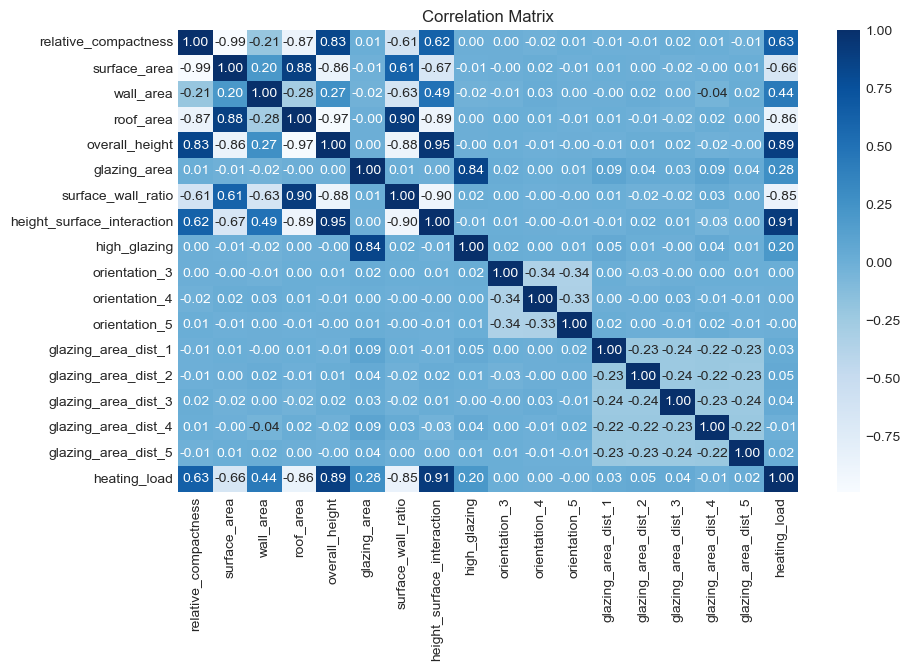

In [135]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [136]:
print("Correlations with Target (heating load):")
correlations = correlation_matrix['heating_load'].abs().sort_values(ascending=False)
correlations = correlations.drop('heating_load')
correlations

Correlations with Target (heating load):


height_surface_interaction    0.909560
overall_height                0.889154
roof_area                     0.863294
surface_wall_ratio            0.853154
surface_area                  0.664684
relative_compactness          0.629314
wall_area                     0.439092
glazing_area                  0.276184
high_glazing                  0.204693
glazing_area_dist_2           0.045239
glazing_area_dist_3           0.036867
glazing_area_dist_1           0.028050
glazing_area_dist_5           0.022630
glazing_area_dist_4           0.006415
orientation_3                 0.004852
orientation_4                 0.003139
orientation_5                 0.002226
Name: heating_load, dtype: float64

# 6. Save Final Data

In [140]:
X_train.to_csv('data/modeling/X_train.csv', index=False)
X_test.to_csv('data/modeling/X_test.csv', index=False)
y_train.to_csv('data/modeling/y_train.csv', index=False)
y_test.to_csv('data/modeling/y_test.csv', index=False)

#equal number of columns
print("Data saved!")
print(f"  X_Train.csv: {X_train.shape[1]} columns (scaled)")
print(f" X_test.csv: {X_test.shape[1]} columns (scaled)")

#no objects, no missing values
X_train.info()
X_test.info()

Data saved!
  X_Train.csv: 17 columns (scaled)
 X_test.csv: 17 columns (scaled)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   relative_compactness        614 non-null    float64
 1   surface_area                614 non-null    float64
 2   wall_area                   614 non-null    float64
 3   roof_area                   614 non-null    float64
 4   overall_height              614 non-null    float64
 5   glazing_area                614 non-null    float64
 6   surface_wall_ratio          614 non-null    float64
 7   height_surface_interaction  614 non-null    float64
 8   high_glazing                614 non-null    int64  
 9   orientation_3               614 non-null    bool   
 10  orientation_4               614 non-null    bool   
 11  orientation_5               614 non-null    bool   
 12  glazing_area

### Summary
* Added 4 new features, one-hot encoded 2 existing features, scaled numerical features

##### Features Created:
* surface_wall_ratio
* height_surface_interaction
* high_glazing

##### Processing Applied
* One-hot encoded: orientation and glazing_area_dist
* StandardScaler